# Домашнє завдання №5 — Частина 1

## Знайомство з Pandas: коефіцієнт народжуваності в регіонах України

Джерело: [Населення України — Wikipedia](https://uk.wikipedia.org/wiki/Населення_України),
таблиця **«Коефіцієнт народжуваності в регіонах України (1950—2019)»**.

In [1]:
%matplotlib inline
from io import StringIO
from urllib.request import Request, urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
print(f"Pandas version: {pd.__version__}")

Pandas version: 3.0.1


## 1. Читання таблиці методом `read_html` та перші рядки

In [2]:
url = (
    "https://uk.wikipedia.org/wiki/"
    "%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_"
    "%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8"
)

# Wikipedia блокує запити без User-Agent, тому спочатку отримуємо HTML,
# а потім передаємо його методу pd.read_html.
request = Request(url, headers={"User-Agent": "Mozilla/5.0"})
with urlopen(request) as response:
    html = response.read().decode("utf-8")

tables = pd.read_html(StringIO(html), decimal=",", thousands=None)
required_columns = {"Регіон", "1950", "1960", "1970", "1990", "2000", "2012", "2014", "2019"}
df = next(
    table.copy()
    for table in tables
    if required_columns.issubset(set(map(str, table.columns)))
)
df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—


## 2. Кількість рядків і стовпців

In [3]:
print(f"Розмір таблиці: {df.shape}")
print(f"Рядків: {df.shape[0]}, стовпців: {df.shape[1]}")

Розмір таблиці: (28, 9)
Рядків: 28, стовпців: 9


## 3. Заміна символу «—» на `NaN`

In [4]:
df = df.replace("—", np.nan)
df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN


## 4. Типи стовпців до перетворення

In [5]:
df.dtypes

Регіон        str
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014          str
2019          str
dtype: object

## 5. Перетворення нечислових колонок на числові

In [6]:
year_columns = df.columns.drop("Регіон")
df[year_columns] = df[year_columns].apply(pd.to_numeric, errors="coerce")
df.dtypes

Регіон        str
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014      float64
2019      float64
dtype: object

## 6. Частка пропусків у кожній колонці

In [7]:
missing_share = df.isnull().sum() / len(df)
missing_share.rename("Частка пропусків").to_frame()

,Частка пропусків
Регіон,0.000000
1950,0.071429
1960,0.035714
1970,0.035714
1990,0.000000
2000,0.000000
2012,0.000000
2014,0.071429
2019,0.142857


## 7. Видалення останнього рядка з даними по всій Україні

In [8]:
ukraine_row = df.iloc[-1].copy()
df_regions = df.drop(index=df.index[-1]).copy()
print("Видалений рядок:", ukraine_row["Регіон"])
print("Новий розмір:", df_regions.shape)
df_regions.tail()

Видалений рядок: Україна
Новий розмір: (27, 9)


,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
22,Черкаська,20.5,17.9,14.4,12.3,7.5,10.0,9.8,6.4
23,Чернівецька,24.7,21.8,17.0,14.8,10.1,12.8,12.9,9.2
24,Чернігівська,22.0,18.3,12.7,10.8,6.9,9.4,9.0,6.1
25,Київ,NaN,17.4,15.9,12.0,7.3,12.0,12.1,11.0
26,Севастополь,NaN,NaN,NaN,12.5,7.0,12.0,NaN,NaN


## 8. Заповнення пропусків середніми значеннями відповідних стовпців

In [9]:
df_filled = df_regions.copy()
df_filled[year_columns] = df_filled[year_columns].fillna(df_filled[year_columns].mean())
print("Кількість пропусків після заповнення:", int(df_filled.isnull().sum().sum()))
df_filled.head()

Кількість пропусків після заповнення: 0


,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,11.144,8.017391
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.900,7.600000
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.100,10.100000
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.100,7.100000
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.200,8.017391


## 9. Регіони з народжуваністю у 2019 році вище середньої

In [10]:
average_2019 = df_filled["2019"].mean()
regions_above_average = df_filled.loc[df_filled["2019"] > average_2019, "Регіон"].tolist()
print(f"Середнє значення за регіонами у 2019 році: {average_2019:.2f}")
print("Регіони вище середнього:")
print(regions_above_average)

Середнє значення за регіонами у 2019 році: 8.02
Регіони вище середнього:
['Волинська', 'Закарпатська', 'Івано-Франківська', 'Львівська', 'Одеська', 'Рівненська', 'Херсонська', 'Чернівецька', 'Київ']


## 10. Регіон із найвищою народжуваністю у 2014 році

In [11]:
max_2014_index = df_filled["2014"].idxmax()
max_region_2014 = df_filled.loc[max_2014_index, "Регіон"]
max_value_2014 = df_filled.loc[max_2014_index, "2014"]
print(f"Найвища народжуваність у 2014 році: {max_region_2014} — {max_value_2014}")

Найвища народжуваність у 2014 році: Рівненська — 14.8


## Візуалізація 1. Народжуваність по регіонах у 2019 році (обов’язкова діаграма)

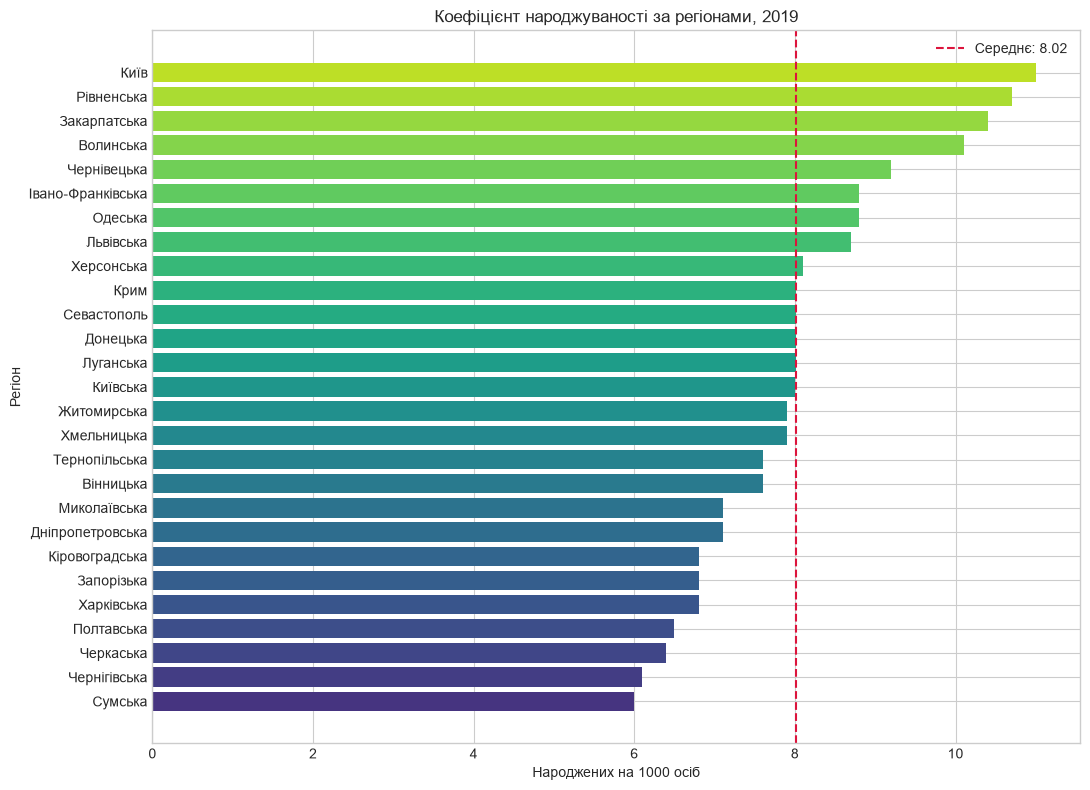

In [12]:
plot_2019 = df_filled.sort_values("2019")
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(plot_2019["Регіон"], plot_2019["2019"], color=plt.cm.viridis(np.linspace(0.15, 0.9, len(plot_2019))))
ax.axvline(average_2019, color="crimson", linestyle="--", label=f"Середнє: {average_2019:.2f}")
ax.set(title="Коефіцієнт народжуваності за регіонами, 2019", xlabel="Народжених на 1000 осіб", ylabel="Регіон")
ax.legend()
plt.tight_layout()
plt.show()

## Візуалізація 2. Динаміка середнього коефіцієнта народжуваності

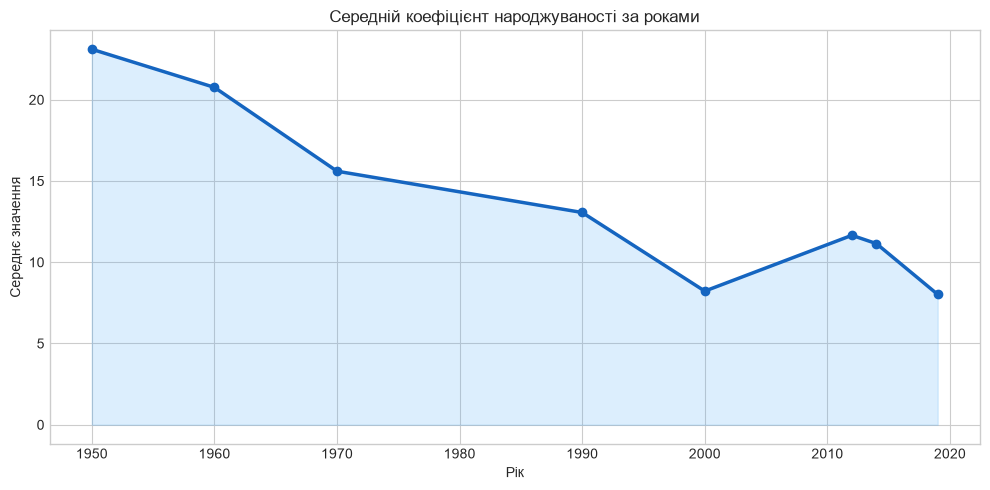

In [13]:
mean_by_year = df_filled[year_columns].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mean_by_year.index.astype(int), mean_by_year.values, marker="o", linewidth=2.5, color="#1565C0")
ax.fill_between(mean_by_year.index.astype(int), mean_by_year.values, alpha=0.18, color="#42A5F5")
ax.set(title="Середній коефіцієнт народжуваності за роками", xlabel="Рік", ylabel="Середнє значення")
plt.tight_layout()
plt.show()

## Візуалізація 3. Розподіл коефіцієнтів за роками

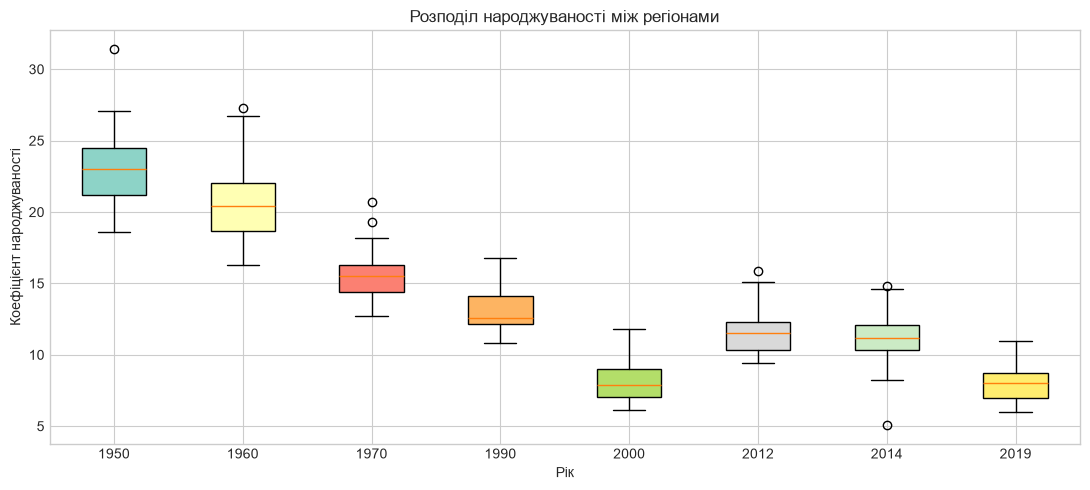

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
box = ax.boxplot([df_filled[column] for column in year_columns], tick_labels=year_columns, patch_artist=True)
for patch, color in zip(box["boxes"], plt.cm.Set3(np.linspace(0, 1, len(year_columns)))):
    patch.set_facecolor(color)
ax.set(title="Розподіл народжуваності між регіонами", xlabel="Рік", ylabel="Коефіцієнт народжуваності")
plt.tight_layout()
plt.show()

## Візуалізація 4. Порівняння 2014 та 2019 років

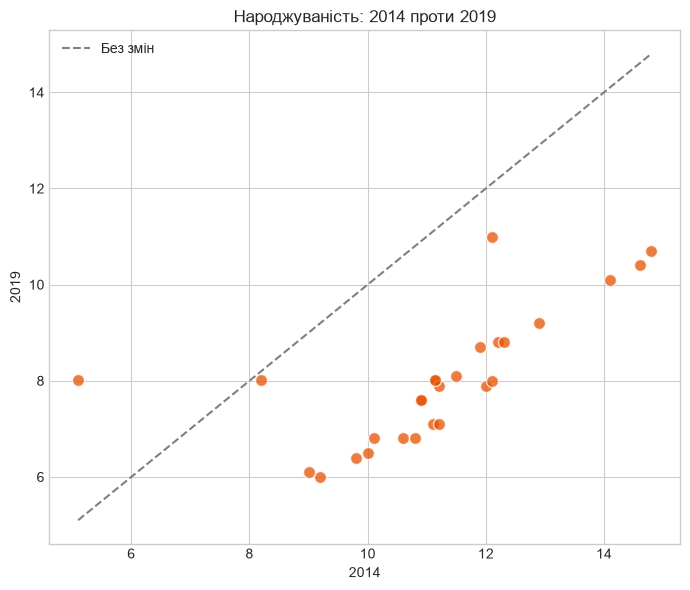

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_filled["2014"], df_filled["2019"], s=75, alpha=0.75, color="#E65100", edgecolor="white")
bounds = [min(df_filled["2014"].min(), df_filled["2019"].min()), max(df_filled["2014"].max(), df_filled["2019"].max())]
ax.plot(bounds, bounds, linestyle="--", color="gray", label="Без змін")
ax.set(title="Народжуваність: 2014 проти 2019", xlabel="2014", ylabel="2019")
ax.legend()
plt.tight_layout()
plt.show()